<a href="https://colab.research.google.com/github/JordanBaker78/Data205_JordanBaker/blob/main/CapstoneProject_Ingestion_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install nflreadpy

In [3]:
import pandas as pd
import nflreadpy  as nfl
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

In [37]:
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
stats_2023 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Stats-2023.csv')
stats_2022 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Stats-2022.csv')
stats_2021 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Stats-2021.csv')
stats_2020 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Stats-2020.csv')
stats_2019 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Stats-2019.csv')

In [5]:
stats = pd.concat((stats_2023, stats_2022, stats_2021, stats_2020, stats_2019))
stats.tail()

,season,event_date,nano,market,name,alias,rush_att,rush_yds,rush_tds,pass_cmp,...,penalty_yds,first_downs,third_down_conv,third_down_att,third_down_conv_pct,fourth_down_conv,fourth_down_att,fourth_down_conv_pct,time_of_possession,boxscore_stats_link
529,2019,2020-01-19,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,27,112,2,23,...,61,27,6,10,0.600,1,1,1.000,1790,https://www.pro-football-reference.com/boxscor...
530,2019,2020-01-19,D5QY6bOxfn8ZL,Green Bay,Packers,GB,16,62,1,31,...,46,21,3,9,0.333,2,2,1.000,1873,https://www.pro-football-reference.com/boxscor...
531,2019,2020-01-19,IwSI92ZDKoazn,San Francisco,49ers,SF,42,285,4,6,...,10,19,4,10,0.400,0,0,0.000,1727,https://www.pro-football-reference.com/boxscor...
532,2019,2020-02-02,IwSI92ZDKoazn,San Francisco,49ers,SF,22,141,1,20,...,45,21,3,8,0.375,0,1,0.000,1607,https://www.pro-football-reference.com/boxscor...
533,2019,2020-02-02,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,29,129,2,26,...,24,26,6,14,0.429,2,3,0.667,1993,https://www.pro-football-reference.com/boxscor...


In [6]:
#Add Column named "rush_avg"
rush_avg = stats['rush_yds'] / stats['rush_att']
stats.insert(8, 'rush_avg', rush_avg)
stats.head()


,season,event_date,nano,market,name,alias,rush_att,rush_yds,rush_avg,rush_tds,...,penalty_yds,first_downs,third_down_conv,third_down_att,third_down_conv_pct,fourth_down_conv,fourth_down_att,fourth_down_conv_pct,time_of_possession,boxscore_stats_link
0,2023,2024-01-28,zyhFXj1nywrm1,Baltimore,Ravens,BAL,16,81,5.062500,0,...,95,16,3,11,0.273,2,2,1.000,1350,https://www.pro-football-reference.com/boxscor...
1,2023,2024-01-28,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,32,89,2.781250,1,...,30,22,8,18,0.444,1,2,0.500,2250,https://www.pro-football-reference.com/boxscor...
2,2023,2024-01-28,IwSI92ZDKoazn,San Francisco,49ers,SF,33,155,4.696970,3,...,20,23,6,12,0.500,0,1,0.000,1932,https://www.pro-football-reference.com/boxscor...
3,2023,2024-01-28,FCuH1wdksA2DQ,Detroit,Lions,DET,29,182,6.275862,3,...,15,28,6,12,0.500,1,3,0.333,1668,https://www.pro-football-reference.com/boxscor...
4,2023,2024-01-21,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,24,146,6.083333,1,...,15,21,1,5,0.200,0,0,0.000,1377,https://www.pro-football-reference.com/boxscor...


In [7]:
#add Column named "pass_avg"
pass_avg = stats['pass_yds'] / stats['pass_cmp']
stats.insert(15, 'pass_avg', pass_avg)
stats.head()

,season,event_date,nano,market,name,alias,rush_att,rush_yds,rush_avg,rush_tds,...,penalty_yds,first_downs,third_down_conv,third_down_att,third_down_conv_pct,fourth_down_conv,fourth_down_att,fourth_down_conv_pct,time_of_possession,boxscore_stats_link
0,2023,2024-01-28,zyhFXj1nywrm1,Baltimore,Ravens,BAL,16,81,5.062500,0,...,95,16,3,11,0.273,2,2,1.000,1350,https://www.pro-football-reference.com/boxscor...
1,2023,2024-01-28,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,32,89,2.781250,1,...,30,22,8,18,0.444,1,2,0.500,2250,https://www.pro-football-reference.com/boxscor...
2,2023,2024-01-28,IwSI92ZDKoazn,San Francisco,49ers,SF,33,155,4.696970,3,...,20,23,6,12,0.500,0,1,0.000,1932,https://www.pro-football-reference.com/boxscor...
3,2023,2024-01-28,FCuH1wdksA2DQ,Detroit,Lions,DET,29,182,6.275862,3,...,15,28,6,12,0.500,1,3,0.333,1668,https://www.pro-football-reference.com/boxscor...
4,2023,2024-01-21,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,24,146,6.083333,1,...,15,21,1,5,0.200,0,0,0.000,1377,https://www.pro-football-reference.com/boxscor...


In [8]:
stats_2019 = stats[stats['season'] == 2019]
stats_2020 = stats[stats['season'] == 2020]
stats_2021 = stats[stats['season'] == 2021]
stats_2022 = stats[stats['season'] == 2022]
stats_2023 = stats[stats['season'] == 2023]
stats_2019.head()

,season,event_date,nano,market,name,alias,rush_att,rush_yds,rush_avg,rush_tds,...,penalty_yds,first_downs,third_down_conv,third_down_att,third_down_conv_pct,fourth_down_conv,fourth_down_att,fourth_down_conv_pct,time_of_possession,boxscore_stats_link
0,2019,2019-09-05,D5QY6bOxfn8ZL,Green Bay,Packers,GB,22,47,2.136364,0,...,71,13,2,12,0.167,0,0,0.0,1863,https://www.pro-football-reference.com/boxscor...
1,2019,2019-09-05,1vVmWGzUZ1rea,Chicago,Bears,CHI,15,46,3.066667,0,...,107,16,3,15,0.200,0,2,0.0,1737,https://www.pro-football-reference.com/boxscor...
2,2019,2019-09-08,mLspw4gJNTQGN,Atlanta,Falcons,ATL,17,73,4.294118,0,...,78,27,2,8,0.250,2,2,1.0,1813,https://www.pro-football-reference.com/boxscor...
3,2019,2019-09-08,AzOs5UWsXusSW,Minnesota,Vikings,MIN,38,172,4.526316,3,...,100,18,5,10,0.500,0,0,0.0,1787,https://www.pro-football-reference.com/boxscor...
4,2019,2019-09-08,3VqeLK0LS9rpw,Buffalo,Bills,BUF,25,128,5.120000,1,...,55,23,5,10,0.500,0,1,0.0,1679,https://www.pro-football-reference.com/boxscor...


In [9]:
#Create dataframes for Rushing Stats for each year
rushing_2019 = stats_2019[['name', 'rush_att', 'rush_yds', 'rush_avg', 'rush_tds']]
rushing_2020 = stats_2020[['name', 'rush_att', 'rush_yds', 'rush_avg', 'rush_tds']]
rushing_2021 = stats_2021[['name', 'rush_att', 'rush_yds', 'rush_avg','rush_tds']]
rushing_2022 = stats_2022[['name', 'rush_att', 'rush_yds', 'rush_avg', 'rush_tds']]
rushing_2023 = stats_2023[['name', 'rush_att', 'rush_yds', 'rush_avg', 'rush_tds']]
rushing_total = stats[['season', 'name', 'rush_att', 'rush_yds', 'rush_avg', 'rush_tds']]
rushing_total.head()

,season,name,rush_att,rush_yds,rush_avg,rush_tds
0,2023,Ravens,16,81,5.062500,0
1,2023,Chiefs,32,89,2.781250,1
2,2023,49ers,33,155,4.696970,3
3,2023,Lions,29,182,6.275862,3
4,2023,Chiefs,24,146,6.083333,1


In [40]:
#Create dataframes for Passing stats for each year
passing_2019 = stats_2019[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_2020 = stats_2020[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_2021 = stats_2021[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_2022 = stats_2022[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_2023 = stats_2023[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_total = stats[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_2019.head()

,name,pass_att,pass_cmp,pass_avg,pass_tds,pass_int,passer_rating,net_pass_yds,times_sacked,yds_sacked_for
0,Packers,30,18,11.277778,1,0,91.389,166,5,37
1,Bears,45,26,8.769231,0,1,62.083,208,5,20
2,Falcons,46,33,9.212121,2,2,85.779,272,4,32
3,Vikings,10,8,12.250000,1,0,140.833,97,1,1
4,Bills,37,24,10.583333,1,2,71.227,242,1,12


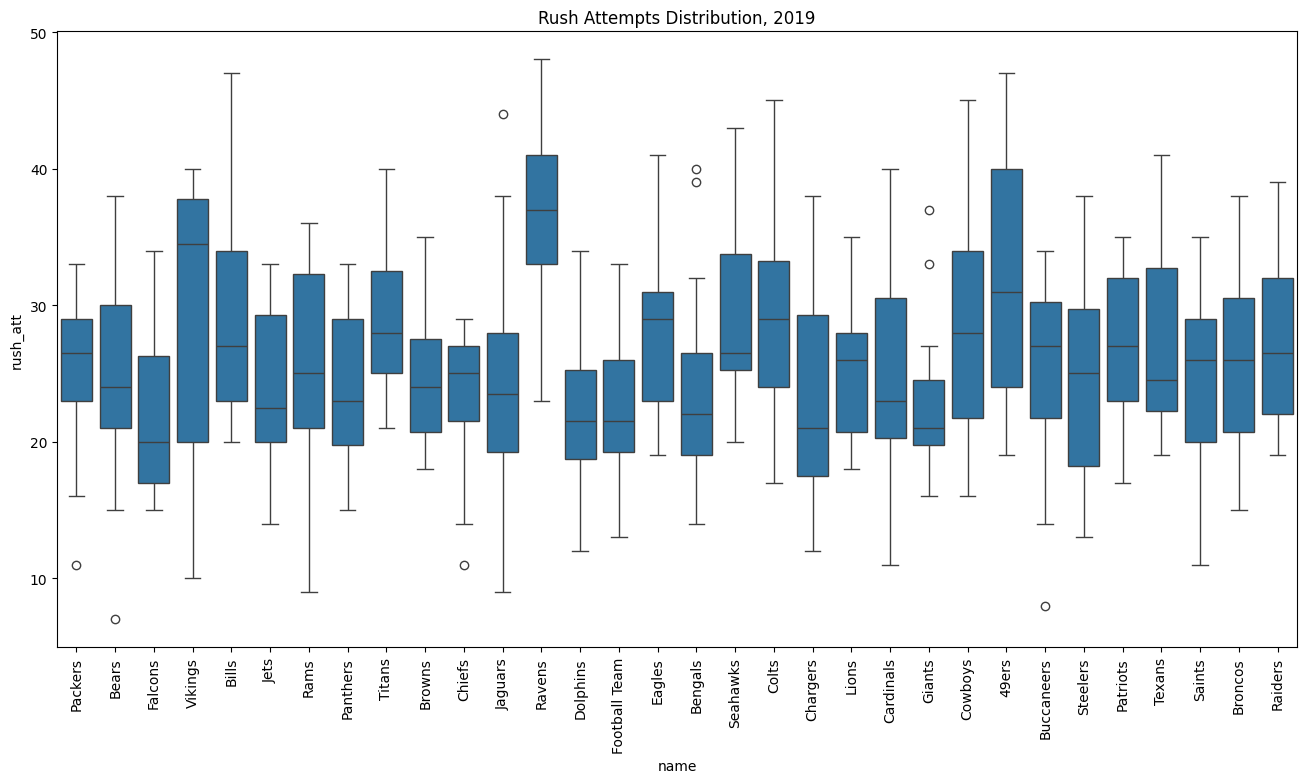

In [19]:
#Plot that shows the distribution of rushing atts by team
plt.figure(figsize=(16, 8))
sns.boxplot(data=rushing_2019, x="name", y="rush_att")
plt.title("Rush Attempts Distribution, 2019")
plt.xticks(rotation=90)
plt.show()

This boxplot simply shows rushing attempts per game by team in the 2019 season. There is a lot of variation in the distribution but the median is between 20 and 30 rushing attempts for nearly every team. The biggest outlier is the Ravens who have a median of over 35 rushing attempts per game and didn't have a game with less than 25 attempts.

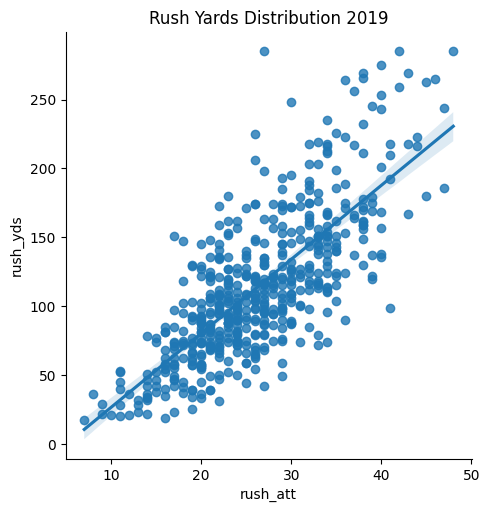

In [35]:
#Plot shows rush atts vs rush yards 2019
sns.lmplot(data=rushing_2019, x="rush_att", y="rush_yds", height= 5, aspect= 1)
plt.title("Rush Yards Distribution 2019")
plt.show()

This plot shows the distribution of rushing yards per attempt (rush average) for every single game in the 2019 season. We can see that the relationship is very linear.

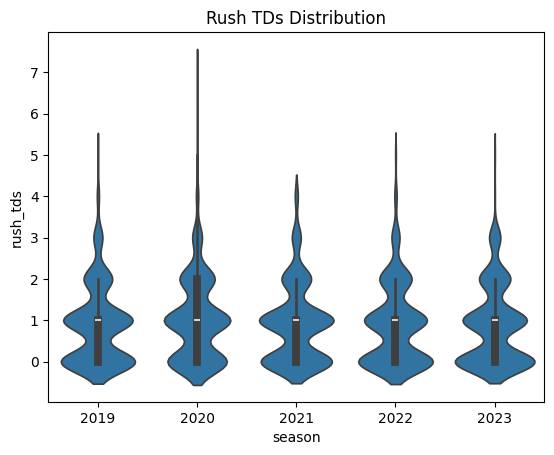

In [ ]:
#violin plot (x = 'season', y = rushing (atts, yds, tds) vs. passing (atts, yds, tds))

sns.violinplot(data=stats, x="season", y="rush_tds")
plt.title("Rush TDs Distribution")
plt.show()

This violin plot shows the ddistribuion of rushing touchdowns in a game per season. The distributions appear to be very similar, with the biggest outlier being one game with 7 rushing touchdowns. The average rushing tds in a game is 1 for every season, which is quite interesting.

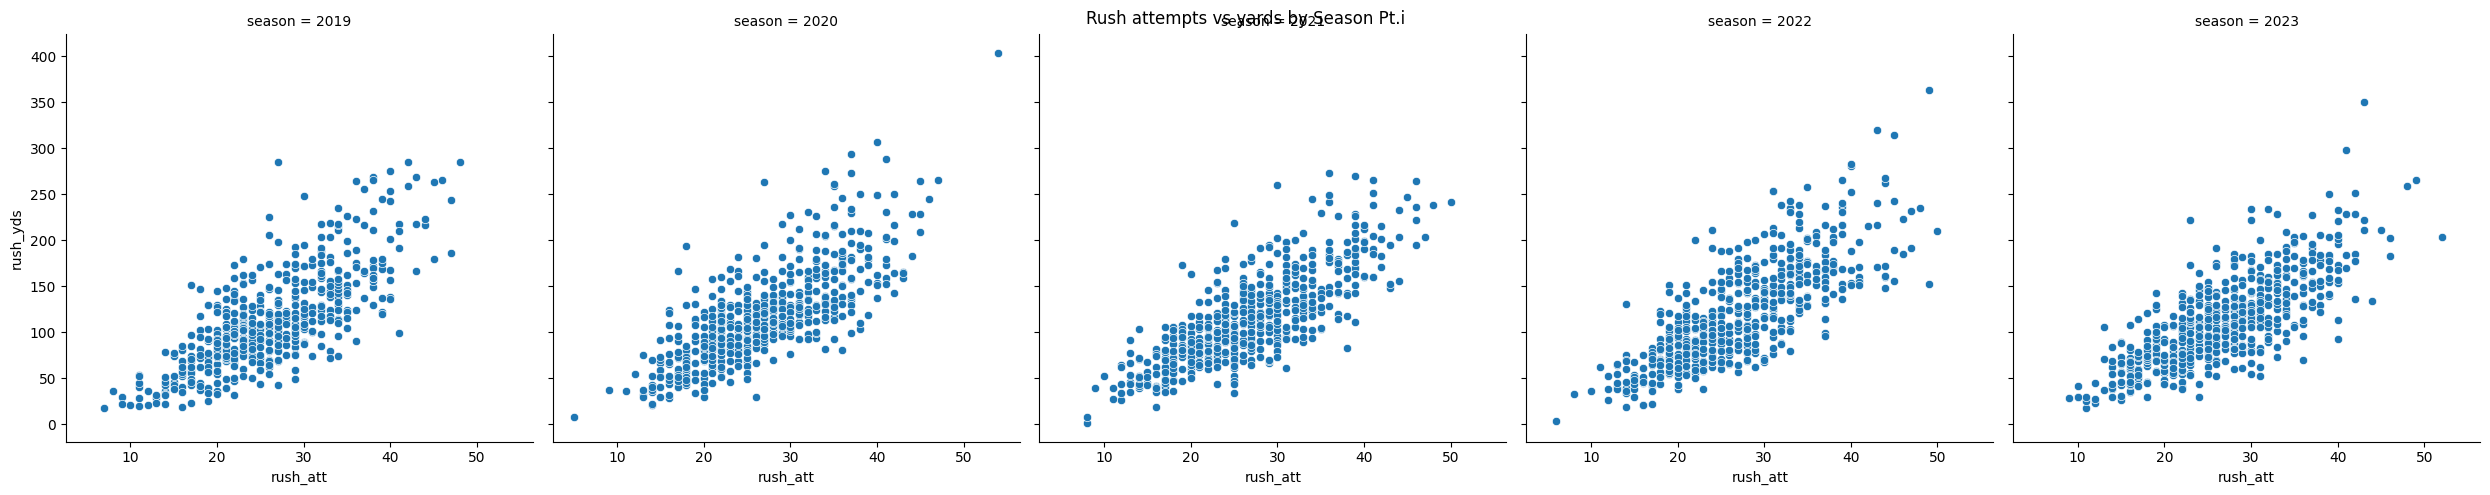

In [ ]:
#Plot to show rushing distribution (attemps vs yards) sperated by season
sns.relplot(data=rushing_total, x="rush_att", y="rush_yds", col="season")
plt.suptitle("Rush attempts vs yards by Season Pt.i")
plt.show()
##I think this might be the coolest visulization so far.

This (group of) plot(s) shows that there is not a big differnce in the running game from season to season. The distribution is extremly similar across each season.

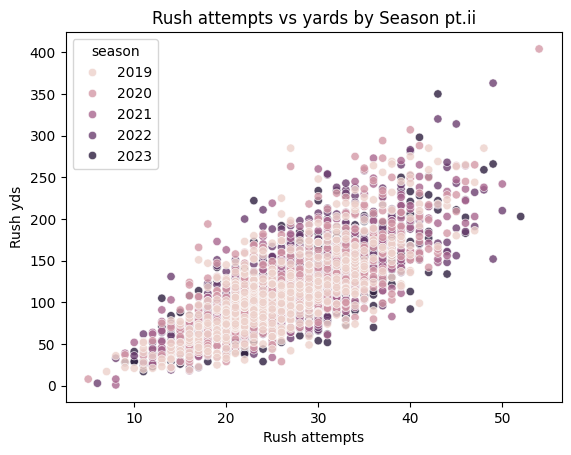

In [36]:
sns.scatterplot(data=stats, x="rush_att", y="rush_yds", hue = "season", alpha = 0.8)
plt.title("Rush attempts vs yards by Season pt.ii")
plt.xlabel("Rush attempts")
plt.ylabel("Rush yds")
plt.show()

This plot also shows the distribution of attempts vs yds, just on one plot and it also shows the similarities across each season.

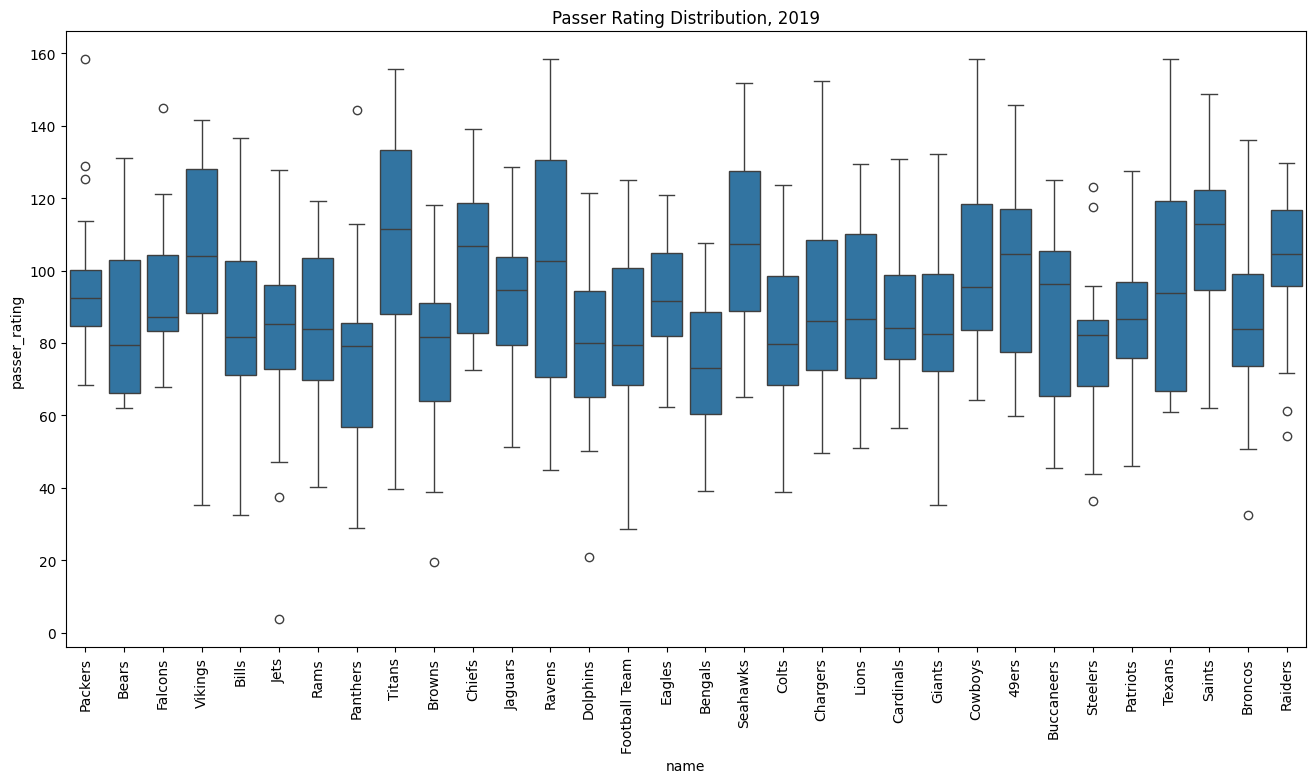

In [43]:
#distribution plot for passer rating by team

plt.figure(figsize=(16, 8))
sns.boxplot(data=passing_2019, x="name", y="passer_rating")
plt.title("Passer Rating Distribution, 2019")
plt.xticks(rotation=90)
plt.show()

Standard plot that shows distribuition of passerrating per game by team in the 2019 season. Another plot with a lot of variation and more outliers than the rushing plot.

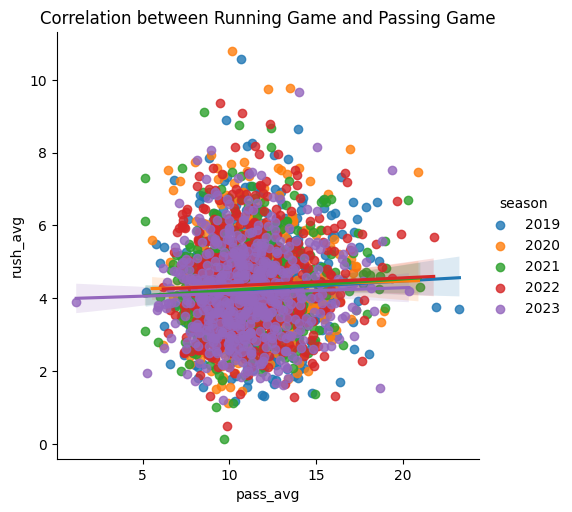

In [ ]:
#Correlation between running game and passing game (linear regression)
sns.lmplot(data=stats, x='pass_avg', y='rush_avg', hue='season')
plt.title("Correlation between Running Game and Passing Game")
plt.show()

This plot displays the correlations between rushing average and passing average. The extremly messy data suggests that there is almost no correlation between rushing average and passing average and passing average is not a good predictor of rushing average, which is very surprising.

In [38]:
#Linear regression model, y = rush_avg, x = pass_avg)
model1 = smf.ols("rush_avg ~ pass_avg", data = stats) .fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               rush_avg   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     5.008
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0253
Time:                        15:08:32   Log-Likelihood:                -4615.1
No. Observations:                2776   AIC:                             9234.
Df Residuals:                    2774   BIC:                             9246.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.0166      0.116     34.716      0.000       3.790       4.243
pass_avg       0.0226      0.010      2.238      0.025       0.003       0.042
==============================================================================
Omnibus:                      208.875   Durbin-Watson:                   1.980
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              301.554
Skew:                           0.614   Prob(JB):                     3.30e-66
Kurtosis:                       4.048   Cond. No.                         55.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

This regression test reinforces the claim that there is little to no correlation between rushing average and passing average and passing average is not a good predictor of rushing average.


- The coeffecient for pass_avg is 0.0226.
- Based on the low p-value of 0.025 we can determine that the "pass_avg" is statistcally significant.
- Based on the R-squared value of 0.002 we can conclude that pass average is on dependent on rush average.